<a href="https://colab.research.google.com/github/OlhaMir/testolha/blob/norma/%D0%9B%D0%A0_2_1_%D0%9C%D1%96%D1%80%D0%BE%D1%88%D0%BD%D0%B8%D0%BA%D0%BE%D0%B2%D0%B0_4-8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import requests

Лабораторна робота 2. Мірошникова, 4-8

---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
tables = pd.read_html(html)
df = tables [2]
df.head()

/tmp/ipykernel_41695/2862643383.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


In [ ]:
df.dtypes

,0
Country/Territory,object
IMF (2026)[1],object
World Bank (2025)[6],object
United Nations (2024)[7],object


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
             .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
             .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


In [ ]:
df['IMF (2026)'] = pd.to_numeric (df ['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df[ 'World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331.0,118350166.0,111565144.0
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [ ]:
part = df.iloc[:, 1:]
col_means = part.mean()
row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
df.iloc[:, 1:] = row_filled.fillna(col_means)
df.isnull().sum()

,0
Country,0
IMF (2026),0
World Bank (2025),0
United Nations (2024),0


5. Ще раз вивести датасет

In [ ]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
212,Saint Martin,1.319229e+06,1.255590e+06,1.043818e+06
213,Federated States of Micronesia,5.210000e+02,5.020000e+02,4.710000e+02
214,Anguilla,4.560000e+02,4.560000e+02,4.560000e+02
215,Cook Islands,4.140000e+02,4.140000e+02,4.140000e+02
216,Kiribati,4.010000e+02,3.490000e+02,3.430000e+02
217,Palau,3.770000e+02,3.450000e+02,3.100000e+02
218,Marshall Islands,3.420000e+02,3.080000e+02,2.810000e+02
219,Nauru,1.960000e+02,1.760000e+02,1.870000e+02
220,Montserrat,8.100000e+01,8.100000e+01,8.100000e+01
221,Tuvalu,6.500000e+01,5.700000e+01,5.600000e+01


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#df.drop_duplicates (inplace=True)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.220000e+02,2.220000e+02,2.220000e+02
mean,1.186681e+06,1.111950e+06,1.043516e+06
std,8.847559e+06,8.297817e+06,7.830342e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.638250e+03,9.642125e+03,9.170750e+03
50%,5.024150e+04,4.835900e+04,4.322450e+04
75%,3.798190e+05,3.436938e+05,3.048545e+05
max,1.262953e+08,1.183502e+08,1.115651e+08


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df ['IMF_WB_Diff'].max()

country= df [df ['IMF_WB_Diff'] == max_diff] ['Country'].values[0]
print(f'One country has the largest difference between IMF and WB: {max_diff}')

df.head(10)

One country has the largest difference between IMF and WB: 7945165.0


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
0,World,126295331.0,118350166.0,111565144.0,7945165.0
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0


United States has the largest difference between IMF and WB.

9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr (df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr (df ['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9999853366658337
Correlation between IMF and UN: 0.9999614839862514
Correlation between WB and UN: 0.9999758882993206


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df ['IMF (2026)'].mean()
mean_IMF

np.float64(1186681.3962548936)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(1111950.006214771)

In [ ]:
mean_UN = df ['United Nations (2024)'].mean()
mean_UN

np.float64(1043515.9672418897)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df [df['std'] == max_std] ['Country'].values [0]
print (f'(country) has the highest standard deviation: {max_std}')
df.head (10)

(country) has the highest standard deviation: 55721978.507490404


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()
print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 126295331.0, Min IMF: 65.0
Max WB: 118350166.0, Min WB: 57.0
Max UN: 111565144.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

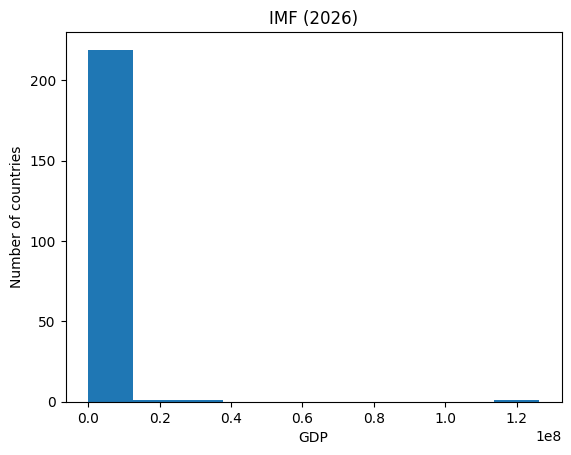

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df ['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()
df.head (10)

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
0,World,126295331.0,118350166.0,111565144.0,7945165.0,5.572198e+07,0.479402,0.479436,0.481589
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.122926,0.124648,0.126470
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.079150,0.078986,0.080911
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.020698,0.020461,0.020115
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.016623,0.017967,0.017380
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.016189,0.016214,0.015911
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.015765,0.016026,0.017060
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.013650,0.013637,0.013643
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.010394,0.010336,0.010277
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.010084,0.010376,0.009382


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [ ]:
df['IMF_UN_Diff'] = abs(df ['IMF_Share']) - df['UN_Share']
df_top10 = df.nlargest (10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
9,Russia,2.656452e+06,2.561310e+06,2.173386e+06,95142.000000,1.202576e+06,0.010084,0.010376,0.009382,0.000702
3,Germany,5.452858e+06,5.050923e+06,4.659929e+06,401935.000000,2.348734e+06,0.020698,0.020461,0.020115,0.000583
10,Brazil,2.635912e+06,2.279920e+06,2.185822e+06,355992.000000,1.024125e+06,0.010006,0.009236,0.009435,0.000570
16,Turkey,1.640223e+06,1.597293e+06,1.323255e+06,42930.000000,7.518882e+05,0.006226,0.006471,0.005712,0.000514
156,Channel Islands,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502
167,Isle of Man,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502
169,Guam,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502
178,U.S. Virgin Islands,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502
180,Faroe Islands,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502
208,Northern Mariana Islands,1.319229e+06,1.255590e+06,1.043818e+06,63638.823613,5.832921e+05,0.005008,0.005086,0.004506,0.000502


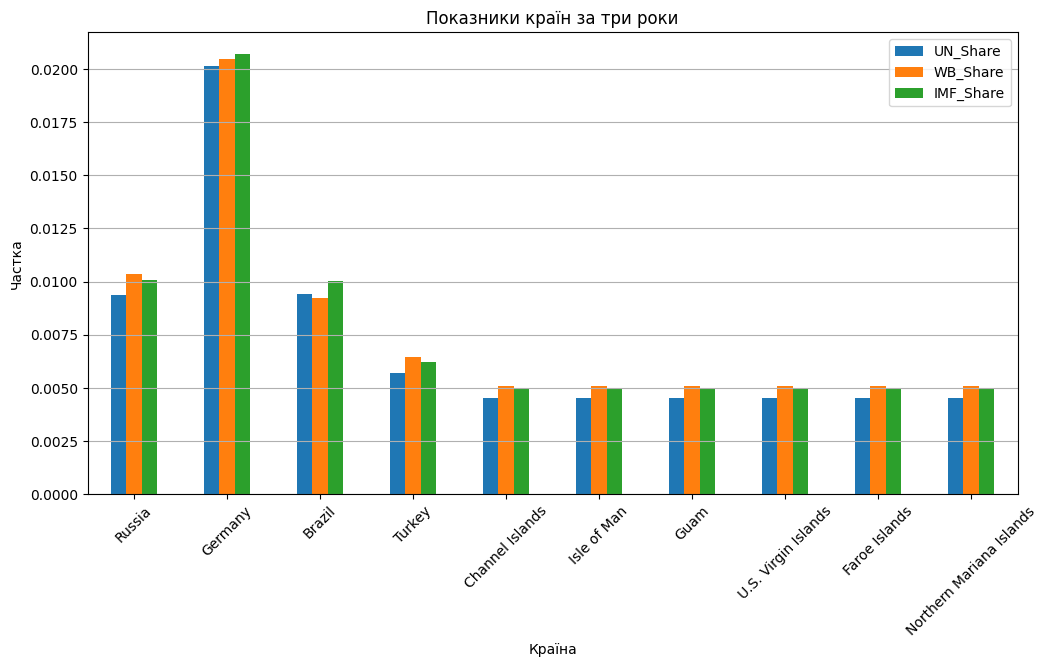

In [ ]:
df_top10.plot(
    x='Country',
    y=['UN_Share', 'WB_Share', 'IMF_Share'],
    kind='bar',
    figsize=(12, 6)
)

plt.title('Показники країн за три роки')
plt.xlabel('Країна')
plt.ylabel('Частка')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

Стабільне зростання показника спостерігається у багатьох країнах з топ-10, зокрема, у Німеччини. Для частини країн показник змінюється нерівномірно: після зростання у другому році відбувається зниження у третьому (Росія), або навпаки (Бразилія). Отже, не всі країни демонструють стабільне зростання чи спад протягом трьох років.